# Camber Sands — multi-model AROME correction (driver notebook)

All logic lives in the **`hyper_local_wind`** package — this notebook just drives it:
`prepare` (decrypt + QC + features) -> `build_windows` -> `train_model` -> `predict` -> `comparison_table`.

- The merged dataset is **encrypted**; set `ARCHIVE_KEY` before running.
- We train an **AROME-only** and a **multi-model** (AROME + UKV + ICON-D2) corrector on identical windows.
- Target = `observed - AROME` residual; corrected = AROME + residual.

In [1]:
%matplotlib inline
import os, sys
from pathlib import Path
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
sys.path.insert(0, str(Path('..').resolve()))   # repo root -> import the package
import hyper_local_wind as hlw

cfg = hlw.Config()
DATA = Path('..')/'data'
MERGED = DATA/'station_53_camber-sands_red-house_merged.parquet.enc'
KEY = os.environ.get('ARCHIVE_KEY')
if not KEY:
    raise RuntimeError('ARCHIVE_KEY env var not set - needed to decrypt the merged archive')
print('hyper_local_wind ready | history', cfg.history_hours, 'horizon', cfg.horizon_hours, 'hidden', cfg.hidden)

hyper_local_wind ready | history 10 horizon 24 hidden 32


## 1. Decrypt, quality-control & window

In [2]:
df, n_dead = hlw.prepare(MERGED, KEY)
data = hlw.build_windows(df, cfg)
print(f'{len(df):,} clean rows (dropped {n_dead} dead-sensor) -> {data.history_features.shape[0]:,} windows')
print('channels  arome:', [len(i) for i in data.channel_indices("arome")],
      ' multimodel:', [len(i) for i in data.channel_indices("multimodel")])

23,980 clean rows (dropped 1831 dead-sensor) -> 22,309 windows
channels  arome: [11, 8]  multimodel: [19, 16]


## 2. Train AROME-only and multi-model correctors (identical windows)

In [3]:
model_arome, info_arome = hlw.train_model(data, 'arome', cfg)
model_mm,    info_mm    = hlw.train_model(data, 'multimodel', cfg)
print(f"AROME-only  best epoch {info_arome['best_epoch']}")
print(f"multi-model best epoch {info_mm['best_epoch']}")

AROME-only  best epoch 15
multi-model best epoch 8


## 3. Predict & evaluate (per-lead wind RMSE, kt)

In [4]:
corr_arome = hlw.predict(model_arome, data, data.val_idx, 'arome')
corr_mm    = hlw.predict(model_mm,    data, data.val_idx, 'multimodel')
table = hlw.comparison_table(data, {'GRU_AROME': corr_arome['wind'], 'GRU_multimodel': corr_mm['wind']})
mean = table.mean().round(3)
imp_gru = 100*(mean.GRU_AROME-mean.GRU_multimodel)/mean.GRU_AROME
imp_raw = 100*(mean.AROME_raw-mean.GRU_multimodel)/mean.AROME_raw
print('mean RMSE over 24h:'); print(mean.to_string())
print(f'\nmulti-model: {imp_gru:+.1f}% vs AROME-only GRU | {imp_raw:+.1f}% vs raw AROME')
table.loc[[1,3,6,12,18,24]].round(2)

mean RMSE over 24h:
AROME_raw         3.495
persistence       7.179
GRU_AROME         2.256
GRU_multimodel    1.972

multi-model: +12.6% vs AROME-only GRU | +43.6% vs raw AROME


,AROME_raw,persistence,GRU_AROME,GRU_multimodel
lead_h,,,,
1,3.49,2.17,1.76,1.64
3,3.49,4.16,2.20,1.93
6,3.49,6.02,2.28,1.99
12,3.50,7.83,2.29,2.00
18,3.50,8.61,2.30,2.00
24,3.50,8.99,2.30,2.00


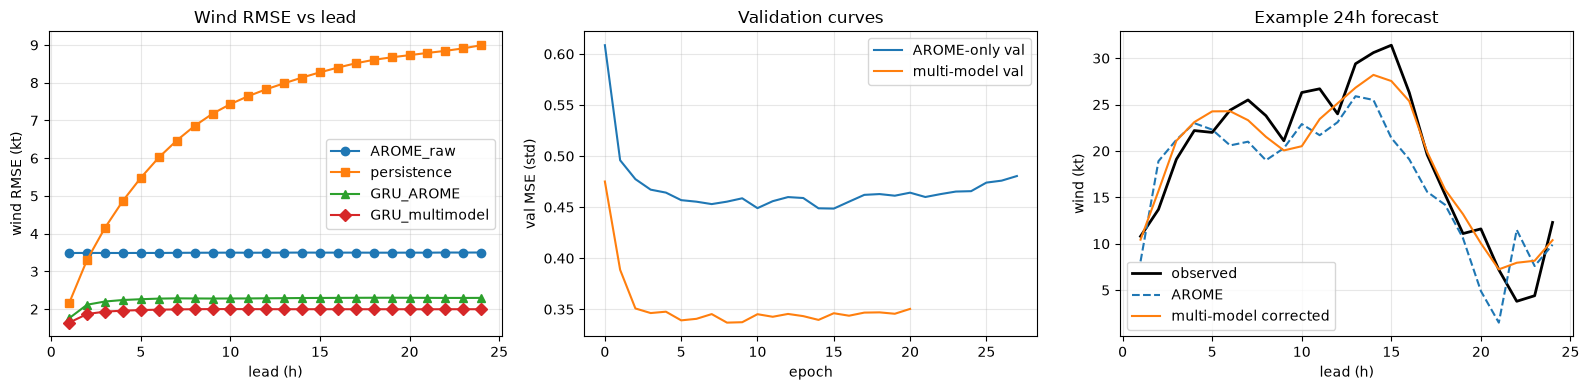

In [5]:
val_idx, leads = data.val_idx, np.arange(1, data.horizon_hours+1)
fig, ax = plt.subplots(1,3, figsize=(16,4))
for col, stl in [('AROME_raw','o-'),('persistence','s-'),('GRU_AROME','^-'),('GRU_multimodel','D-')]:
    ax[0].plot(leads, table[col], stl, label=col)
ax[0].set_xlabel('lead (h)'); ax[0].set_ylabel('wind RMSE (kt)'); ax[0].set_title('Wind RMSE vs lead'); ax[0].legend(); ax[0].grid(alpha=.3)
ax[1].plot(info_arome['history']['val'], label='AROME-only val'); ax[1].plot(info_mm['history']['val'], label='multi-model val')
ax[1].set_xlabel('epoch'); ax[1].set_ylabel('val MSE (std)'); ax[1].set_title('Validation curves'); ax[1].legend(); ax[1].grid(alpha=.3)
example = 120
ax[2].plot(leads, data.observed_wind[val_idx][example],'k-',lw=2,label='observed')
ax[2].plot(leads, data.arome_forecast_wind[val_idx][example],'--',label='AROME')
ax[2].plot(leads, corr_mm['wind'][example],'-',label='multi-model corrected')
ax[2].set_xlabel('lead (h)'); ax[2].set_ylabel('wind (kt)'); ax[2].set_title('Example 24h forecast'); ax[2].legend(); ax[2].grid(alpha=.3)
plt.tight_layout(); plt.show()

## 4. Save
Logic lives in `hyper_local_wind/` (`data`, `model`, `train`, `inference`, `evaluate`, `crypto`); `hlw.save_model` stores weights + channel names + scalers so the model can be reloaded for inference via `hlw.load_model`.

In [6]:
MODELS = Path('..')/'models'; MODELS.mkdir(exist_ok=True)
hlw.save_model(model_mm, data, 'multimodel', MODELS/'camber_multimodel_gru_24h.pt')
table.round(4).to_json('camber_multimodel_perlead_metrics.json', indent=2)
print('saved -> models/camber_multimodel_gru_24h.pt and notebooks/camber_multimodel_perlead_metrics.json')

saved -> models/camber_multimodel_gru_24h.pt and notebooks/camber_multimodel_perlead_metrics.json
